In [2]:
import os
import sys
import pandas as pd
import numpy as np
import nibabel as nib
import h5py as h5

subject = 1

sys.path.append(os.path.abspath(".."))

from utils.config import Configuration, load_config

config = load_config("../config.yaml")

tsv_dir = os.path.join("..", config.nsd_data.nsddata_responses_tsv_dir)

In [3]:
t_test_rois_lh = "../data/t_test_roi/subj_01/lh.subj01.cleanedrois_3_0.mgz"
t_test_rois_rh = "../data/t_test_roi/subj_01/rh.subj01.cleanedrois_3_0.mgz"


import nibabel as nib



# Load MGZ files
lh_img = nib.load(t_test_rois_lh)
rh_img = nib.load(t_test_rois_rh)
lh = lh_img.get_fdata()
rh = rh_img.get_fdata()
t_rois = np.concatenate((np.squeeze(lh), np.squeeze(rh)))

t_indices = np.where(t_rois != 0)[0]

roi_sizes = []
roi_indices = []

for roi in range(1, 9):
    roi_indices_set = np.where(t_rois[t_indices] == roi)[0]
    roi_indices.append(roi_indices_set)
    roi_sizes.append(len(roi_indices_set))

In [4]:
subject_id = 1

tsv_path = os.path.join(
        tsv_dir,
        "ppdata",
        f"subj{subject_id:02d}",
        "behav",
        "responses.tsv",
    )

    # having all of the array loaded at once results in memory pressure
    # reduce to needed subset!

tsv_data = pd.read_csv(tsv_path, sep="\t")

In [5]:
from collections import Counter
import numpy as np
from collections import defaultdict



results = []

sample_dict = defaultdict(list)

for i in range(1, 40+1):
    result_dict_session = {}

    entries_session = tsv_data[tsv_data["SESSION"] == i]
    entry_ids = entries_session["73KID"].tolist()

    for entry_id in list(set(entry_ids)):
        entries_sample = entries_session[entries_session["73KID"] == entry_id]


        result_dict_session[entry_id] = {
            "count" : len(entries_sample) 
        }

        for row_i, row in entries_sample.iterrows():
            sample_dict[entry_id].append({
                "session" : int(row["SESSION"]),
                "index" : row_i,
                "session_index" : row_i - (int(row["SESSION"])-1)*750,
                "73KID" : entry_id
            }) 

            result_dict_session[entry_id]["session"] = int(row["SESSION"])
            result_dict_session[entry_id]["index"] = row_i
            result_dict_session[entry_id]["session_index"] = row_i - (int(row["SESSION"])-1)*750


    if i==1:
        print(result_dict_session)

    results.append(result_dict_session)








{2050: {'count': 1, 'session': 1, 'index': 454, 'session_index': 454}, 38919: {'count': 1, 'session': 1, 'index': 215, 'session_index': 215}, 28681: {'count': 1, 'session': 1, 'index': 252, 'session_index': 252}, 38925: {'count': 3, 'session': 1, 'index': 493, 'session_index': 493}, 49171: {'count': 1, 'session': 1, 'index': 106, 'session_index': 106}, 28691: {'count': 3, 'session': 1, 'index': 517, 'session_index': 517}, 59411: {'count': 1, 'session': 1, 'index': 545, 'session_index': 545}, 47126: {'count': 2, 'session': 1, 'index': 664, 'session_index': 664}, 10263: {'count': 1, 'session': 1, 'index': 697, 'session_index': 697}, 38937: {'count': 2, 'session': 1, 'index': 719, 'session_index': 719}, 51228: {'count': 2, 'session': 1, 'index': 374, 'session_index': 374}, 18469: {'count': 1, 'session': 1, 'index': 51, 'session_index': 51}, 22565: {'count': 1, 'session': 1, 'index': 651, 'session_index': 651}, 28711: {'count': 2, 'session': 1, 'index': 658, 'session_index': 658}, 8236: {'

In [6]:
res_matrix = np.zeros((40, 40))
for i in range(40):
    entry_ids_i = list(results[i].keys())

    n_repeats = 0
    for entry_id in entry_ids_i:
        if results[i][entry_id]["count"] > 1:
            n_repeats += 1
    

    res_matrix[i, i] = n_repeats

    for j in range(i + 1, 40):
        entry_ids_j = list(results[j].keys())
        overlap = set(entry_ids_i) & set(entry_ids_j)
        res_matrix[i, j] = len(overlap)
        res_matrix[j, i] = len(overlap)

<Axes: >

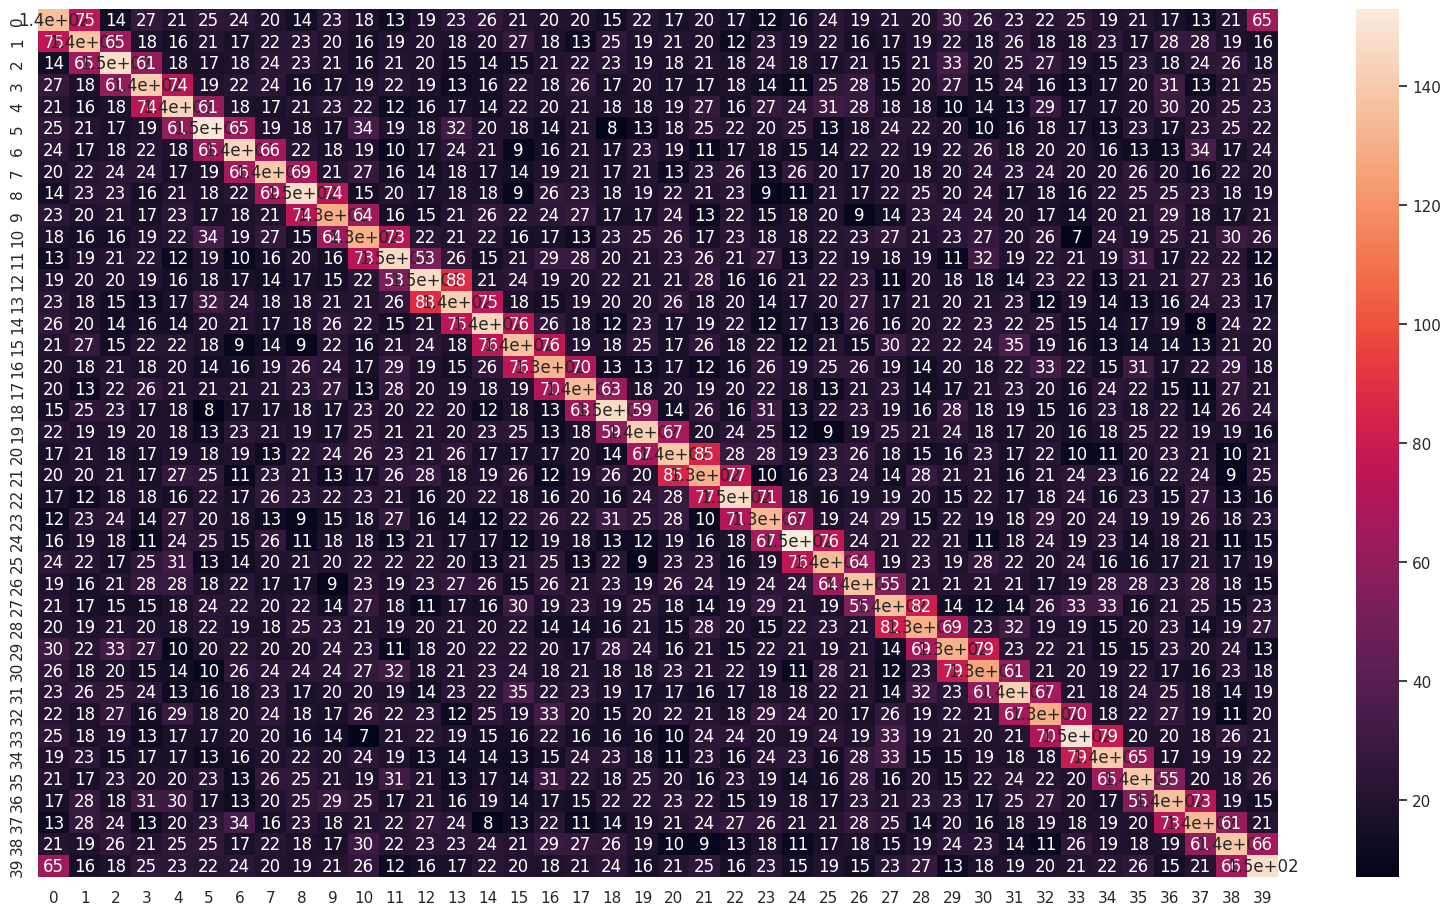

In [7]:
import seaborn as sns
sns.set_theme(rc={'figure.figsize':(20,11.27)})
sns.heatmap(res_matrix, annot=True)

In [8]:
t_test_rois_lh = "../data/t_test_roi/subj_01/lh.subj01.cleanedrois_3_0.mgz"
t_test_rois_rh = "../data/t_test_roi/subj_01/rh.subj01.cleanedrois_3_0.mgz"

# Load MGZ files
lh_img = nib.load(t_test_rois_lh)
rh_img = nib.load(t_test_rois_rh)
lh = lh_img.get_fdata()
rh = rh_img.get_fdata()
t_rois = np.concatenate((np.squeeze(lh), np.squeeze(rh)))

t_indices = np.where(t_rois != 0)[0]  # Indizes der nicht-Null ROIs
unique_rois = np.unique(t_rois[t_rois > 0])  # ROIs von 1 bis 8

In [9]:
def return_session_betas(session, indices):
    betas_dir = os.path.join(config.nsd_data.nsddata_betas_dir, "ppdata", f"subj{subject:02d}", "nativesurface", "betas_fithrf_GLMdenoise_RR")
    beta_lh = os.path.join(betas_dir, f"lh.betas_session{session:02d}.hdf5")
    beta_rh = os.path.join(betas_dir, f"rh.betas_session{session:02d}.hdf5")

    with h5.File(beta_lh, 'r') as f:
        betas_lh = f['betas'][:]

    with h5.File(beta_rh, 'r') as f:
        betas_rh = f['betas'][:]

    betas_concat = np.concatenate((betas_lh, betas_rh), axis=1)
    betas_filtered = betas_concat[:, t_indices]

    return betas_filtered[indices, :], betas_concat[indices, :]

    

In [10]:
def display_sample_correlation(betas):
    import matplotlib.pyplot as plt
    import numpy as np
    import matplotlib.gridspec as gridspec
    import scipy.spatial.distance as dist 

    # Beispielhafte Daten: 3 Arrays mit zufälliger Anzahl an Voxel pro ROI
    num_rois = 8
    n_samples = len(betas)

    # Berechne die relative Breite jeder Spalte basierend auf der Anzahl der Voxel
    col_widths = [size / sum(roi_sizes) for size in roi_sizes]

    # Erstelle das Grid mit dynamischer Spaltenbreite
    fig = plt.figure(figsize=(12, 3))
    gs = gridspec.GridSpec(n_samples, num_rois, width_ratios=col_widths)

    # Erzeuge eine flache Liste von Subplots
    axes = np.array([[fig.add_subplot(gs[i, j]) for j in range(num_rois)] for i in range(n_samples)])

    # Optional: Liste zum Speichern der Korrelationswerte
    roi_correlations = []

    # Heatmaps zeichnen
    for j in range(num_rois):  # Spalten (ROIs)
        roi_indices_set = roi_indices[j]

        # Matrix [n_samples x n_voxels_in_ROI]
        roi_betas = []
        for i in range(n_samples):
            betas_standardized = betas[i][roi_indices_set] / np.std(betas[i][roi_indices_set])
            roi_betas.append(betas_standardized)

            # Zeichne Heatmap
            im = axes[i, j].imshow(betas_standardized.reshape(1, -1),
                                cmap="coolwarm", aspect="auto", vmin=-2, vmax=2)
            axes[i, j].set_xticks([])
            axes[i, j].set_yticks([])

            if i == 0:
                axes[i, j].set_title(f"ROI {j+1}")

        # Korrelation berechnen über Samples (Voxel sind Merkmale)
        roi_betas_matrix = np.array(roi_betas)  # shape: [n_samples, n_voxels]
        corr_matrix = np.corrcoef(roi_betas_matrix)  # [n_samples x n_samples]
        avg_corr = np.mean(corr_matrix[np.triu_indices(n_samples, k=1)])  # nur obere Dreieck, ohne Diagonale
        roi_correlations.append(avg_corr)

    # Farbskala hinzufügen, falls gewünscht
    # cbar = fig.colorbar(im, ax=axes.ravel(), orientation="vertical", fraction=0.02, pad=0.05)
    # cbar.set_label("Beta Values")

    plt.tight_layout()
    plt.show()

    # Korrelationsübersicht anzeigen
    for j, corr in enumerate(roi_correlations):
        print(f"ROI {j+1}: Durchschnittliche Korrelation zwischen Samples = {corr:.3f}")

In [28]:
def display_sample_distance(betas, metric="correlation", **metric_kwargs):
    import matplotlib.pyplot as plt
    import numpy as np
    import matplotlib.gridspec as gridspec
    from scipy.spatial.distance import pdist, squareform

    # Beispielhafte Daten: 3 Arrays mit zufälliger Anzahl an Voxel pro ROI
    num_rois = 8
    n_samples = len(betas)

    # Berechne die relative Breite jeder Spalte basierend auf der Anzahl der Voxel
    col_widths = [size / sum(roi_sizes) for size in roi_sizes]

    # Erstelle das Grid mit dynamischer Spaltenbreite
    fig = plt.figure(figsize=(12, 3))
    gs = gridspec.GridSpec(n_samples, num_rois, width_ratios=col_widths)

    # Erzeuge eine flache Liste von Subplots
    axes = np.array([[fig.add_subplot(gs[i, j]) for j in range(num_rois)] for i in range(n_samples)])

    # Optional: Liste zum Speichern der Korrelationswerte
    roi_distances = []

    # Heatmaps zeichnen
    for j in range(num_rois):  # Spalten (ROIs)
        roi_indices_set = roi_indices[j]

        # Matrix [n_samples x n_voxels_in_ROI]
        roi_betas = []
        for i in range(n_samples):
            betas_standardized = betas[i][roi_indices_set] / np.std(betas[i][roi_indices_set])
            roi_betas.append(betas_standardized)

            # Zeichne Heatmap
            im = axes[i, j].imshow(betas_standardized.reshape(1, -1),
                                cmap="coolwarm", aspect="auto", vmin=-2, vmax=2)
            axes[i, j].set_xticks([])
            axes[i, j].set_yticks([])

            if i == 0:
                axes[i, j].set_title(f"ROI {j+1}")

        roi_betas_matrix = np.array(roi_betas)  # shape: [n_samples, n_voxels]

        # Distanzmatrix berechnen
        try:
            dist_matrix = squareform(pdist(roi_betas_matrix, metric=metric, **metric_kwargs))
            upper = dist_matrix[np.triu_indices(n_samples, k=1)]
            
            # Für bestimmte Metriken Ähnlichkeit anzeigen statt Distanz
            if metric in ["correlation", "cosine"]:
                avg_similarity = 1 - np.mean(upper)
                roi_distances.append(avg_similarity)
                print(f"ROI {j+1}: Durchschnittliche **Ähnlichkeit** zwischen Samples ({metric}) = {avg_similarity:.3f}")
            else:
                avg_distance = np.mean(upper)
                roi_distances.append(avg_distance)
                print(f"ROI {j+1}: Durchschnittlicher **Abstand** zwischen Samples ({metric}) = {avg_distance:.3f}")

        except Exception as e:
            print(f"Fehler bei ROI {j+1} mit Metrik '{metric}': {e}")
            roi_distances.append(np.nan)


    plt.tight_layout()
    plt.show()

    for j, dist in enumerate(roi_distances):
        print(f"ROI {j+1}: Durchschnittlicher Abstand zwischen Samples ({metric}) = {dist:.3f}")


In [33]:
import pandas as pd

face_ids = pd.read_excel("../data/labels/subj_01/faces/faces_final.xlsx")["nsdId"].tolist()
face_ids

[18170,
 34200,
 16649,
 28170,
 58157,
 57811,
 46323,
 2125,
 18960,
 67148,
 1136,
 17623,
 41853,
 12258,
 65222,
 45528,
 3920,
 15516,
 39302,
 46807,
 25070,
 60749,
 59180,
 60514,
 63255,
 67671,
 14270,
 15567,
 17651,
 19471,
 40325,
 41126,
 58839,
 14631,
 21193,
 40530,
 61766,
 65730,
 23077,
 27059,
 29699,
 31790,
 34652,
 45454,
 58457,
 67899,
 5823,
 6504,
 15510,
 15977,
 31655,
 39256,
 42013,
 46097,
 49796,
 55396,
 55724,
 63277,
 7627,
 8743,
 23462,
 28588,
 30016,
 38458,
 40568,
 47128,
 50802,
 53810,
 60496,
 62005,
 65421,
 72340,
 30174,
 31375,
 32741,
 43105,
 50579,
 50719,
 55545,
 55896,
 65519,
 67908,
 71151,
 72412,
 5892,
 10459,
 10479,
 18888,
 21856,
 31394,
 37128,
 39727,
 46647,
 49375,
 49446,
 49678,
 51570,
 55600,
 57701,
 71624,
 6679,
 15438,
 21375,
 25999,
 29901,
 30134,
 31472,
 35887,
 38402,
 39390,
 40364,
 40881,
 43042,
 47988,
 50659,
 60126,
 61247,
 67034,
 72745,
 1346,
 3611,
 4578,
 5202,
 7414,
 8557,
 8956,
 14407,



Entry ID: 18888

Entry ID: 42195
Duplicate session: 19
Session indices: [474, 590]
ROI 1: Durchschnittliche **Ähnlichkeit** zwischen Samples (correlation) = 0.628
ROI 2: Durchschnittliche **Ähnlichkeit** zwischen Samples (correlation) = 0.147
ROI 3: Durchschnittliche **Ähnlichkeit** zwischen Samples (correlation) = -0.012
ROI 4: Durchschnittliche **Ähnlichkeit** zwischen Samples (correlation) = 0.156
ROI 5: Durchschnittliche **Ähnlichkeit** zwischen Samples (correlation) = 0.100
ROI 6: Durchschnittliche **Ähnlichkeit** zwischen Samples (correlation) = 0.416
ROI 7: Durchschnittliche **Ähnlichkeit** zwischen Samples (correlation) = 0.610
ROI 8: Durchschnittliche **Ähnlichkeit** zwischen Samples (correlation) = -0.086


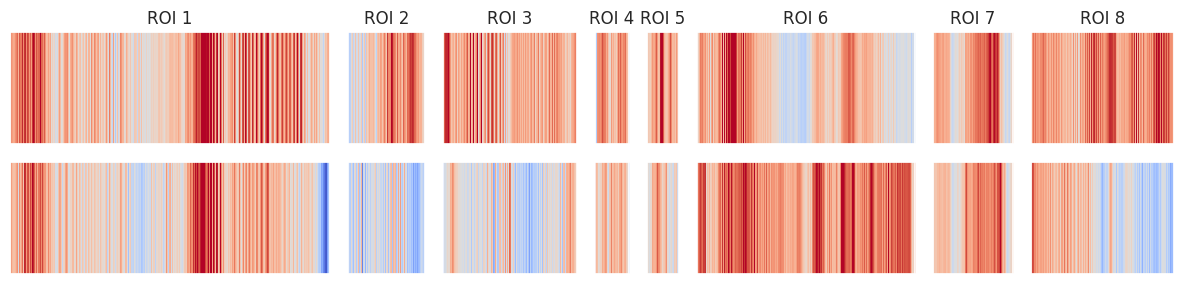

ROI 1: Durchschnittlicher Abstand zwischen Samples (correlation) = 0.628
ROI 2: Durchschnittlicher Abstand zwischen Samples (correlation) = 0.147
ROI 3: Durchschnittlicher Abstand zwischen Samples (correlation) = -0.012
ROI 4: Durchschnittlicher Abstand zwischen Samples (correlation) = 0.156
ROI 5: Durchschnittlicher Abstand zwischen Samples (correlation) = 0.100
ROI 6: Durchschnittlicher Abstand zwischen Samples (correlation) = 0.416
ROI 7: Durchschnittlicher Abstand zwischen Samples (correlation) = 0.610
ROI 8: Durchschnittlicher Abstand zwischen Samples (correlation) = -0.086

Entry ID: 65519
Duplicate session: 4
Session indices: [57, 112]
ROI 1: Durchschnittliche **Ähnlichkeit** zwischen Samples (correlation) = 0.704
ROI 2: Durchschnittliche **Ähnlichkeit** zwischen Samples (correlation) = 0.666
ROI 3: Durchschnittliche **Ähnlichkeit** zwischen Samples (correlation) = 0.262
ROI 4: Durchschnittliche **Ähnlichkeit** zwischen Samples (correlation) = 0.382
ROI 5: Durchschnittliche **Äh

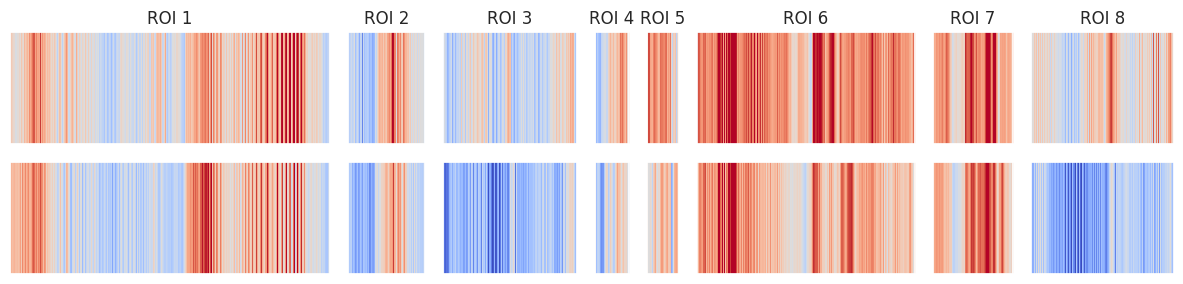

ROI 1: Durchschnittlicher Abstand zwischen Samples (correlation) = 0.704
ROI 2: Durchschnittlicher Abstand zwischen Samples (correlation) = 0.666
ROI 3: Durchschnittlicher Abstand zwischen Samples (correlation) = 0.262
ROI 4: Durchschnittlicher Abstand zwischen Samples (correlation) = 0.382
ROI 5: Durchschnittlicher Abstand zwischen Samples (correlation) = 0.131
ROI 6: Durchschnittlicher Abstand zwischen Samples (correlation) = 0.620
ROI 7: Durchschnittlicher Abstand zwischen Samples (correlation) = 0.586
ROI 8: Durchschnittlicher Abstand zwischen Samples (correlation) = 0.337


In [34]:
from collections import defaultdict, Counter

sample_dict_dict = dict(sample_dict)
counter = 0

for entry_id, entries in sample_dict_dict.items():
    nsd_id = entries[0]["73KID"]
    if nsd_id in face_ids:
        pass
    else:
        continue

    if counter == 2:
        break
    
    print(f"\nEntry ID: {entry_id}")
    
    # Collect session -> list of session_index
    session_to_indices = defaultdict(list)
    for entry in entries:
        session = entry["session"]
        session_index = entry["session_index"]
        session_to_indices[session].append(session_index)
    
    # Find duplicate sessions (i.e., sessions with more than one sample)
    for session, indices in session_to_indices.items():
        if len(indices) > 1:
            print(f"Duplicate session: {session}")
            print(f"Session indices: {indices}")

            betas_filtered, betas = return_session_betas(session, indices)
            display_sample_distance(betas_filtered)
            counter += 1




Entry ID: 2050
Duplicate session: 35
Session indices: [403, 516]


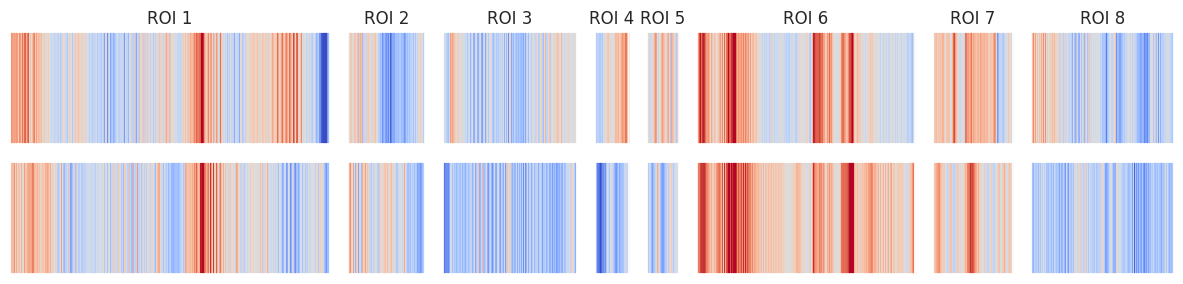

ROI 1: Durchschnittliche Korrelation zwischen Samples = 0.260
ROI 2: Durchschnittliche Korrelation zwischen Samples = -0.066
ROI 3: Durchschnittliche Korrelation zwischen Samples = 0.047
ROI 4: Durchschnittliche Korrelation zwischen Samples = 0.291
ROI 5: Durchschnittliche Korrelation zwischen Samples = -0.205
ROI 6: Durchschnittliche Korrelation zwischen Samples = 0.679
ROI 7: Durchschnittliche Korrelation zwischen Samples = 0.008
ROI 8: Durchschnittliche Korrelation zwischen Samples = 0.020

Entry ID: 38919

Entry ID: 28681
Duplicate session: 40
Session indices: [522, 607]


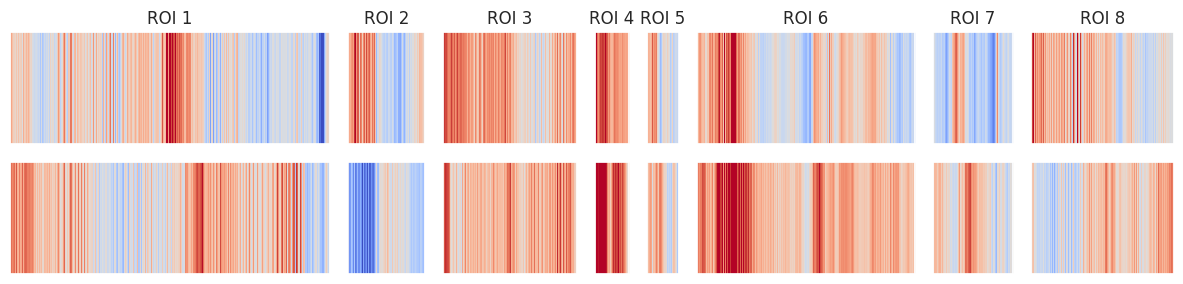

ROI 1: Durchschnittliche Korrelation zwischen Samples = 0.086
ROI 2: Durchschnittliche Korrelation zwischen Samples = -0.492
ROI 3: Durchschnittliche Korrelation zwischen Samples = 0.302
ROI 4: Durchschnittliche Korrelation zwischen Samples = 0.551
ROI 5: Durchschnittliche Korrelation zwischen Samples = 0.044
ROI 6: Durchschnittliche Korrelation zwischen Samples = 0.587
ROI 7: Durchschnittliche Korrelation zwischen Samples = -0.136
ROI 8: Durchschnittliche Korrelation zwischen Samples = 0.157


In [21]:
from collections import defaultdict, Counter

sample_dict_dict = dict(sample_dict)
counter = 0

for entry_id, entries in sample_dict_dict.items():
    if counter == 2:
        break
    
    print(f"\nEntry ID: {entry_id}")
    
    # Collect session -> list of session_index
    session_to_indices = defaultdict(list)
    for entry in entries:
        session = entry["session"]
        session_index = entry["session_index"]
        session_to_indices[session].append(session_index)
    
    # Find duplicate sessions (i.e., sessions with more than one sample)
    for session, indices in session_to_indices.items():
        if len(indices) > 1:
            print(f"Duplicate session: {session}")
            print(f"Session indices: {indices}")

            betas_filtered, betas = return_session_betas(session, indices)
            display_sample_correlation(betas_filtered)
            counter += 1



In [13]:


t_indices.shape

(27321,)

In [14]:
clipping_val = 2

for i, beta in enumerate(betas):
    lh_path = os.path.join(
                    config.nsd_data.freesurfer_dir,
                    "subj01",
                    "label",
                    f"lh.sample{i}.mgz",
                )
    rh_path = os.path.join(
                    config.nsd_data.freesurfer_dir,
                    "subj01",
                    "label",
                    f"rh.sample{i}.mgz",
                )
    
    betas_standardized = betas_filtered[i].copy() 
    for j in range(0, 8):
        roi_indices_set = roi_indices[j]
        betas_standardized[roi_indices_set] = betas_filtered[i][roi_indices_set] / np.std(betas_filtered[i][roi_indices_set])
        

    # lh_data = betas_standardized[:lh.shape[0]]
    # rh_data = betas_standardized[lh.shape[0]:]
    lh_data = np.empty(lh.shape[0])
    rh_data = np.empty((betas[i].shape[0] - lh.shape[0]))
    print(lh_data.shape)
    print(rh_data.shape)


    # betas_filtered_standardized = betas_filtered[i] / np.std(betas_filtered[i])
    for t_i, val in enumerate(betas_standardized):
        if t_indices[t_i] < lh.shape[0]:
            lh_data[t_indices[t_i]] = val
        else:
            rh_data[t_indices[t_i] - lh.shape[0]] = val
        
    print(betas[i].shape)
    print(lh_data.shape)
    print(rh_data.shape)

    lh_data = np.clip(lh_data, -clipping_val, clipping_val) + clipping_val
    rh_data = np.clip(rh_data, -clipping_val, clipping_val) + clipping_val

    

    

    # Save updated left hemisphere mask

    img = nib.Nifti1Image(np.expand_dims(lh_data, axis=(1, 2)), np.eye(4))
    nib.loadsave.save(img, lh_path)
    #nib.save(out_mask_lh, lh_path)
    print(f"Saved updated left hemisphere mask to: {lh_path}")


    img = nib.Nifti1Image(np.expand_dims(rh_data, axis=(1, 2)), np.eye(4))
    nib.loadsave.save(img, rh_path)
    #nib.save(out_mask_rh, rh_path)
    print(f"Saved updated right hemisphere mask to: {rh_path}")



(227021,)
(226601,)
(453622,)
(227021,)
(226601,)
Saved updated left hemisphere mask to: /media/harveylab/storage2/stan-thesis/data/nsddata/freesurfer/subj01/label/lh.sample0.mgz


/tmp/ipykernel_356328/460828811.py:42: RuntimeWarning: invalid value encountered in add
  lh_data = np.clip(lh_data, -clipping_val, clipping_val) + clipping_val
/media/Working/master_thesis/venv/lib/python3.10/site-packages/nibabel/spatialimages.py:550: UserWarning: Using large vector Freesurfer hack; header will not be compatible with SPM or FSL
  hdr.set_data_shape(shape)


Saved updated right hemisphere mask to: /media/harveylab/storage2/stan-thesis/data/nsddata/freesurfer/subj01/label/rh.sample0.mgz
(227021,)
(226601,)
(453622,)
(227021,)
(226601,)
Saved updated left hemisphere mask to: /media/harveylab/storage2/stan-thesis/data/nsddata/freesurfer/subj01/label/lh.sample1.mgz
Saved updated right hemisphere mask to: /media/harveylab/storage2/stan-thesis/data/nsddata/freesurfer/subj01/label/rh.sample1.mgz


In [15]:
clipping_val = 1.9

for i, beta in enumerate(betas):
    lh_path = os.path.join(
                    config.nsd_data.freesurfer_dir,
                    "subj01",
                    "label",
                    f"lh.sample{i}.mgz",
                )
    rh_path = os.path.join(
                    config.nsd_data.freesurfer_dir,
                    "subj01",
                    "label",
                    f"rh.sample{i}.mgz",
                )
    
    betas_standardized = betas[i] / np.std(betas[i]) 
    
        

    # lh_data = betas_standardized[:lh.shape[0]]
    # rh_data = betas_standardized[lh.shape[0]:]
    lh_data = np.empty(lh.shape[0])
    rh_data = np.empty((betas[i].shape[0] - lh.shape[0]))
    print(lh_data.shape)
    print(rh_data.shape)


    # betas_filtered_standardized = betas_filtered[i] / np.std(betas_filtered[i])
    for t_i, val in enumerate(betas_standardized):
        if t_i < lh.shape[0]:
            lh_data[t_i] = val
        else:
            rh_data[t_i- lh.shape[0]]  = val
        
    print(betas[i].shape)
    print(lh_data.shape)
    print(rh_data.shape)

    lh_data = np.clip(lh_data, -clipping_val, clipping_val) + clipping_val
    rh_data = np.clip(rh_data, -clipping_val, clipping_val) + clipping_val

    # Berechne den Skalenfaktor für Werte außerhalb der soften Grenzen
    scale = ((2*clipping_val-0.1) - 0.1) / (2*clipping_val - 0)


    # Linear transformieren in [0.1, 3.9]
    arr_scaled = 0.1 + scale * (lh_data - 0)

    # Mittelwert korrigieren (falls nötig)
    mean_before = np.mean(lh_data)
    mean_after = np.mean(arr_scaled)
    shift = mean_before - mean_after


    # Werte gleichmäßig verschieben, um Mittelwert wieder auf 2 zu bringen
    lh_data = arr_scaled + shift


    # Linear transformieren in [0.1, 3.9]
    arr_scaled = 0.1 + scale * (rh_data - 0)

    # Mittelwert korrigieren (falls nötig)
    mean_before = np.mean(rh_data)
    mean_after = np.mean(arr_scaled)
    shift = mean_before - mean_after


    # Werte gleichmäßig verschieben, um Mittelwert wieder auf 2 zu bringen
    rh_data = arr_scaled + shift

    

    

    # Save updated left hemisphere mask

    img = nib.Nifti1Image(np.expand_dims(lh_data, axis=(1, 2)), np.eye(4))
    nib.loadsave.save(img, lh_path)
    #nib.save(out_mask_lh, lh_path)
    print(f"Saved updated left hemisphere mask to: {lh_path}")


    img = nib.Nifti1Image(np.expand_dims(rh_data, axis=(1, 2)), np.eye(4))
    nib.loadsave.save(img, rh_path)
    #nib.save(out_mask_rh, rh_path)
    print(f"Saved updated right hemisphere mask to: {rh_path}")



(227021,)
(226601,)
(453622,)
(227021,)
(226601,)
Saved updated left hemisphere mask to: /media/harveylab/storage2/stan-thesis/data/nsddata/freesurfer/subj01/label/lh.sample0.mgz
Saved updated right hemisphere mask to: /media/harveylab/storage2/stan-thesis/data/nsddata/freesurfer/subj01/label/rh.sample0.mgz
(227021,)
(226601,)
(453622,)
(227021,)
(226601,)
Saved updated left hemisphere mask to: /media/harveylab/storage2/stan-thesis/data/nsddata/freesurfer/subj01/label/lh.sample1.mgz
Saved updated right hemisphere mask to: /media/harveylab/storage2/stan-thesis/data/nsddata/freesurfer/subj01/label/rh.sample1.mgz


In [16]:
import nibabel as nib
import numpy as np

def load_surface_coords(subject='subj01', hemi='lh', surf='white'):
    surf_path = f'/media/harveylab/storage2/stan-thesis/data/nsddata/freesurfer/{subject}/surf/{hemi}.{surf}'
    coords, _ = nib.freesurfer.read_geometry(surf_path)  # coords: [n_vertices, 3]
    return coords


all_coords = load_surface_coords(subject='subj01', hemi='lh')  # or 'rh'



In [17]:
all_coords.shape

(227021, 3)